# Statistical Analysis Project — Comprehensive Synthetic Dataset

A complete statistics workflow: data cleaning, descriptive statistics,
hypothesis testing (parametric & non-parametric), correlation, and
regression (linear & logistic) — built on a synthetic dataset with mixed
variable types (continuous, ordinal, nominal, count, binary, time).

**Tools:** pandas, numpy, scipy, statsmodels, pingouin, matplotlib, seaborn

All reusable logic lives in `src/` as importable modules:
```
src/
  data_cleaning.py        # missing values, outliers, type fixes
  descriptive_stats.py     # summary statistics
  hypothesis_tests.py      # t-tests, ANOVA, chi-square, correlation, effect sizes
  regression.py            # linear & logistic regression
  visualization.py         # reusable plotting functions
```


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg

from data_cleaning import full_cleaning_pipeline
from descriptive_stats import numeric_summary_table, categorical_summary
from hypothesis_tests import (test_normality, independent_ttest, mann_whitney, cohens_d_independent,
                               paired_ttest, wilcoxon_test, cohens_d_paired,
                               one_way_anova, kruskal_wallis, tukey_posthoc, eta_squared,
                               chi_square_test, cramers_v,
                               pearson_correlation, spearman_correlation)
from regression import linear_regression, logistic_regression, odds_ratios
from visualization import plot_histogram, plot_boxplot, plot_scatter, plot_correlation_heatmap, plot_bar_counts

pd.set_option('display.max_columns', None)


## 1. Data Cleaning

The raw dataset has missing values in 4 columns (income, height_cm,
children_count, job_satisfaction_1to5), a handful of impossible values
in exam_score (negative scores), and weight_kg/bmi needed regeneration
due to a generation bug (see `src/data_cleaning.py` for the full,
documented reasoning behind every decision).

In [2]:
df_raw = pd.read_csv('../data/raw_dataset.csv')
print('Raw shape:', df_raw.shape)
df_raw.isna().sum()


Raw shape: (2000, 22)


id                        0
gender                    0
age                       0
education                 0
city                      0
group                     0
treatment                 0
income                   60
height_cm                40
weight_kg                 0
bmi                       0
score_before              0
score_after               0
performance               0
job_satisfaction_1to5    30
children_count           20
study_hours_week          0
exam_score                0
passed_exam               0
smoker                    0
has_disease               0
register_date             0
dtype: int64

In [3]:
df = full_cleaning_pipeline('../data/raw_dataset.csv')
print('Missing values after cleaning:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
df.head()


Missing values after cleaning: 0
Duplicate rows: 0


,id,gender,age,education,city,group,treatment,income,height_cm,weight_kg,bmi,score_before,score_after,performance,job_satisfaction_1to5,children_count,study_hours_week,exam_score,passed_exam,smoker,has_disease,register_date
0,1,Male,51.6,Bachelor,Shiraz,A,Placebo,1560.0,163.5,64.8,24.24,57.2,46.1,52.9,4,1,18.5,94.0,1,No,No,2023-06-26
1,2,Female,32.6,High School,Mashhad,A,Drug,1987.0,167.2,62.3,22.29,42.1,59.0,48.4,4,3,1.2,51.4,1,No,No,2023-02-09
2,3,Female,47.2,PhD,Mashhad,C,Drug,2399.0,168.5,70.3,24.76,74.7,83.1,41.7,3,2,3.1,58.3,1,No,No,2023-11-19
3,4,Female,39.8,High School,Tehran,A,Placebo,1286.0,173.0,86.1,28.77,48.3,50.9,32.6,4,0,2.2,49.8,1,No,No,2023-07-02
4,5,Male,49.2,Bachelor,Tehran,A,Placebo,2316.0,148.3,42.8,19.46,45.1,46.4,43.3,5,2,5.8,65.5,1,No,No,2023-10-26


## 2. Descriptive Statistics

In [4]:
numeric_cols = ['age', 'income', 'height_cm', 'weight_kg', 'bmi',
                'score_before', 'score_after', 'performance', 'study_hours_week', 'exam_score']
numeric_summary_table(df, numeric_cols)


,age,income,height_cm,weight_kg,bmi,score_before,score_after,performance,study_hours_week,exam_score
mean,35.097450,1479.409625,169.867500,67.254000,23.235355,60.065850,64.839200,50.747600,6.047600,57.885807
median,34.900000,1328.500000,169.867500,66.400000,23.185000,60.300000,65.350000,50.700000,5.000000,55.800000
mode,18.000000,3233.875000,169.867500,40.000000,19.130000,60.000000,64.900000,50.200000,5.600000,100.000000
variance,97.270364,483293.784459,80.163972,185.570529,15.543860,146.483871,182.548107,111.113091,18.903436,230.541919
std,9.862574,695.193343,8.953434,13.622427,3.942570,12.103052,13.511037,10.541019,4.347808,15.183607
max,69.000000,3233.875000,197.900000,121.200000,38.420000,100.000000,100.000000,93.100000,37.300000,100.000000
min,18.000000,278.000000,136.200000,40.000000,13.820000,16.600000,20.400000,17.500000,0.100000,1.213599
skewness,0.215370,0.880058,-0.006219,0.425702,0.206329,-0.121777,-0.077406,0.043891,1.513809,0.609269
kurtosis,-0.379606,0.196070,0.098265,0.076814,-0.263256,0.094949,-0.180778,0.148690,3.507768,0.375664


In [5]:
categorical_summary(df['education'])


,count,percentage
education,,
Bachelor,798,39.90
Master,514,25.70
High School,499,24.95
PhD,189,9.45


### Visualizing key distributions

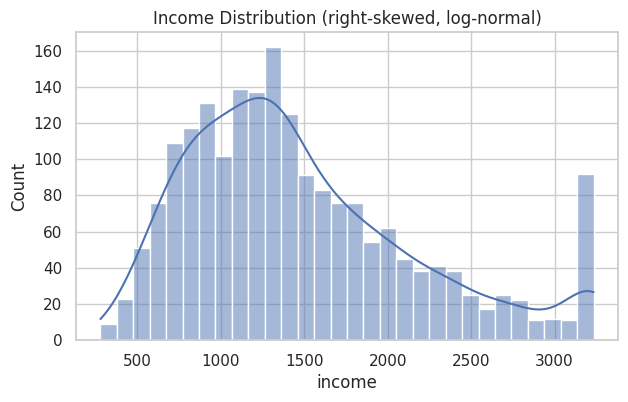

In [6]:
plot_histogram(df, 'income', save_as='hist_income.png',
               title='Income Distribution (right-skewed, log-normal)')
plt.show()


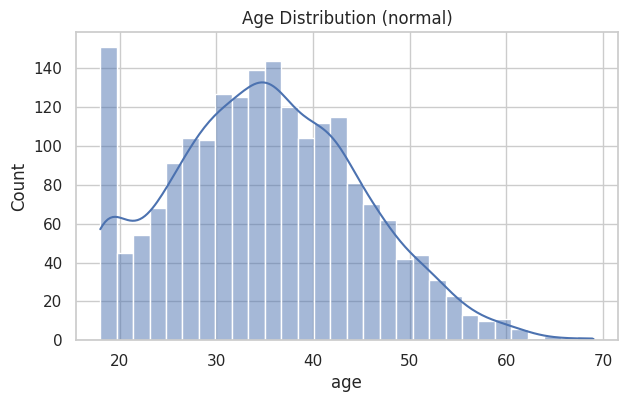

In [7]:
plot_histogram(df, 'age', save_as='hist_age.png', title='Age Distribution (normal)')
plt.show()


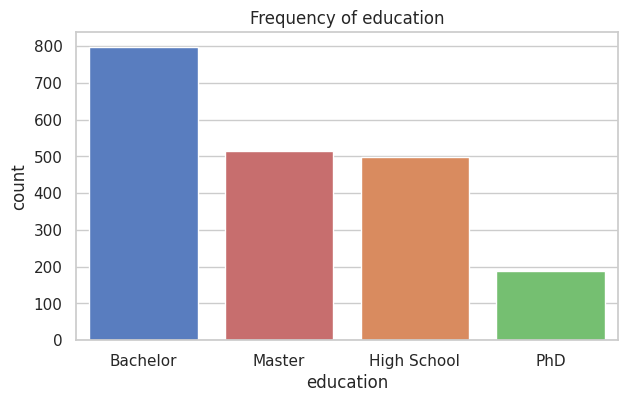

In [8]:
plot_bar_counts(df, 'education', save_as='bar_education.png')
plt.show()


## 3. Normality Testing

Shapiro-Wilk test (H0: data is normally distributed) on the key
variables used in the hypothesis tests below.

In [9]:
drug_group = df[df['treatment'] == 'Drug']['score_after']
placebo_group = df[df['treatment'] == 'Placebo']['score_after']

pd.DataFrame([
    {'variable': 'score_after | Drug', **test_normality(drug_group)},
    {'variable': 'score_after | Placebo', **test_normality(placebo_group)},
    {'variable': 'study_hours_week', **test_normality(df['study_hours_week'])},
    {'variable': 'exam_score', **test_normality(df['exam_score'])},
])


,variable,statistic,p_value,is_normal (alpha=0.05)
0,score_after | Drug,0.996356,1.456168e-02,False
1,score_after | Placebo,0.997956,3.069234e-01,True
2,study_hours_week,0.888376,9.194970e-36,False
3,exam_score,0.970626,8.415144e-20,False


## 4. Research Question 1 — Does the drug improve scores vs placebo?

**Variables:** `treatment` (Drug/Placebo) vs `score_after`
**Test:** Independent t-test (Welch) + Mann-Whitney U (non-parametric check) + Cohen's d

In [10]:
result_t = independent_ttest(drug_group, placebo_group)
result_mw = mann_whitney(drug_group, placebo_group)
d = cohens_d_independent(drug_group, placebo_group)

print(result_t)
print(result_mw)
print('Cohen d:', d)
print('Drug mean:', drug_group.mean(), '| Placebo mean:', placebo_group.mean())


{'test': 'Independent t-test (Welch)', 'statistic': np.float64(12.366457323142445), 'p_value': np.float64(6.7498337315682855e-34)}
{'test': 'Mann-Whitney U', 'statistic': np.float64(651577.0), 'p_value': np.float64(1.8289612736083742e-32)}
Cohen d: 0.5526373854767334
Drug mean: 68.24805318138651 | Placebo mean: 61.048785638859556


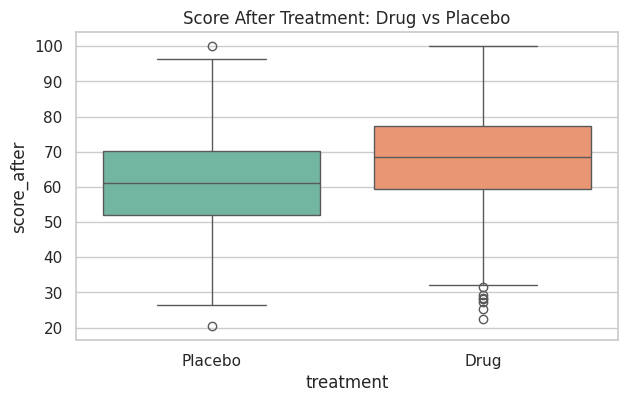

In [11]:
plot_boxplot(df, 'score_after', 'treatment', save_as='box_treatment.png',
            title='Score After Treatment: Drug vs Placebo')
plt.show()


**Conclusion:** Both the parametric and non-parametric tests agree the
difference is statistically significant (p < 0.001). Cohen's d = 0.55
indicates a medium-sized effect — the drug group scored about 7.2 points
higher on average (68.25 vs 61.05).

## 5. Research Question 2 — Did scores change from before to after?

**Variables:** `score_before` vs `score_after` (same individuals)
**Test:** Paired t-test + Wilcoxon signed-rank + Cohen's d (paired)

In [12]:
result_paired = paired_ttest(df['score_before'], df['score_after'])
result_wilcoxon = wilcoxon_test(df['score_before'], df['score_after'])
d_paired = cohens_d_paired(df['score_before'], df['score_after'])
d_paired_pingouin = pg.compute_effsize(df['score_before'], df['score_after'], paired=True, eftype='cohen')

print(result_paired)
print(result_wilcoxon)
print('Cohen d (manual, diff-based):', d_paired)
print('Cohen d (pingouin):', d_paired_pingouin)


{'test': 'Paired t-test', 'statistic': np.float64(-34.62225853080068), 'p_value': np.float64(3.4766795246835957e-206)}
{'test': 'Wilcoxon signed-rank', 'statistic': np.float64(275082.5), 'p_value': np.float64(3.550665379584839e-171)}
Cohen d (manual, diff-based): 0.7741772360944232
Cohen d (pingouin): -0.37215102822845275


**Note on the two Cohen's d values:** the manual formula divides the
mean difference by the standard deviation *of the differences*, while
pingouin's `paired=True` option uses a different pooled standard
deviation in the denominator. Both are valid conventions for paired
Cohen's d — there is no single universal formula — so both are reported
here for transparency.

**Conclusion:** Scores rose significantly from before to after
treatment (p < 0.001), with a medium-to-large effect size.

## 6. Research Question 3 — Does performance differ across groups A, B, C?

**Variables:** `group` (A/B/C) vs `performance`
**Test:** One-way ANOVA + Tukey HSD post-hoc + Eta squared

In [13]:
result_anova = one_way_anova(df, 'performance', 'group')
print(result_anova)

anova_table = eta_squared(df, dv='performance', between='group')
anova_table


{'test': 'One-way ANOVA', 'statistic': np.float64(105.5195820746314), 'p_value': np.float64(2.7336045826871417e-44)}


,Source,SS,DF,MS,F,p_unc,np2
0,group,21229.23323,2,10614.616615,105.519582,2.733605e-44,0.095578
1,Within,200885.83525,1997,100.593808,NaN,NaN,NaN


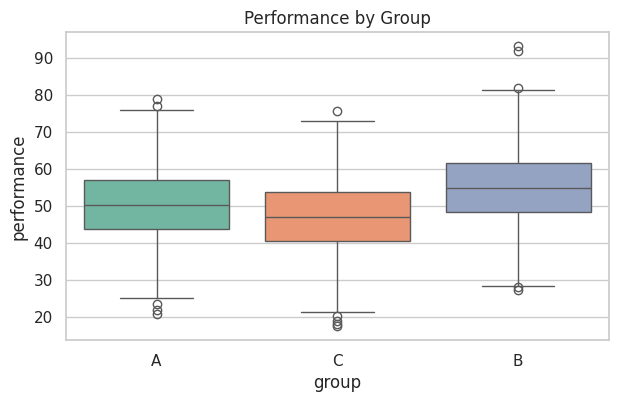

In [14]:
plot_boxplot(df, 'performance', 'group', save_as='box_anova_group.png',
            title='Performance by Group')
plt.show()


In [15]:
tukey_result = tukey_posthoc(df, 'performance', 'group')
print(tukey_result)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B   4.8807   0.0  3.6011  6.1603   True
     A      C  -3.0229   0.0  -4.319 -1.7268   True
     B      C  -7.9036   0.0 -9.1941 -6.6131   True
---------------------------------------------------


**Conclusion:** Performance differs significantly across the three
groups (F = 105.52, p < 0.001, η² = 0.096 — medium-to-large effect).
Tukey's post-hoc test shows all three pairwise comparisons are
significant: Group B scored highest, Group A in the middle, Group C
lowest.

## 7. Research Question 4 — Is smoking associated with disease?

**Variables:** `smoker` (Yes/No) vs `has_disease` (Yes/No)
**Test:** Chi-square test of independence + Cramer's V

In [16]:
crosstab = pd.crosstab(df['smoker'], df['has_disease'])
crosstab


has_disease,No,Yes
smoker,,
No,1355,194
Yes,267,184


In [17]:
result_chi2 = chi_square_test(df, 'smoker', 'has_disease')
v = cramers_v(result_chi2['statistic'], len(df), (2, 2))

print(result_chi2['statistic'], result_chi2['p_value'])
print("Cramer's V:", v)


180.33571118345128 4.093749985798543e-41
Cramer's V: 0.30027962899891436


In [18]:
rates = pd.crosstab(df['smoker'], df['has_disease'], normalize='index') * 100
rates.round(1)


has_disease,No,Yes
smoker,,
No,87.5,12.5
Yes,59.2,40.8


**Conclusion:** Smoking and disease status are significantly
associated (χ²(1) = 180.34, p < 0.001, Cramer's V = 0.30 — medium
effect). 40.8% of smokers have the disease vs only 12.5% of
non-smokers.

## 8. Research Question 5 — Does study time relate to exam score?

**Variables:** `study_hours_week` vs `exam_score`
**Test:** Pearson correlation + Spearman correlation (since study_hours_week is non-normal)

In [19]:
result_pearson = pearson_correlation(df['study_hours_week'], df['exam_score'])
result_spearman = spearman_correlation(df['study_hours_week'], df['exam_score'])
print(result_pearson)
print(result_spearman)


{'method': 'Pearson', 'r': np.float64(0.8287266221632892), 'p_value': np.float64(0.0)}
{'method': 'Spearman', 'rho': np.float64(0.7829918335378019), 'p_value': np.float64(0.0)}


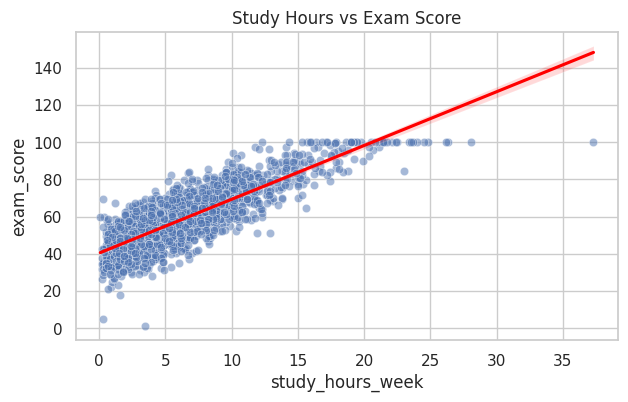

In [20]:
plot_scatter(df, 'study_hours_week', 'exam_score', save_as='scatter_study_exam.png',
            title='Study Hours vs Exam Score')
plt.show()


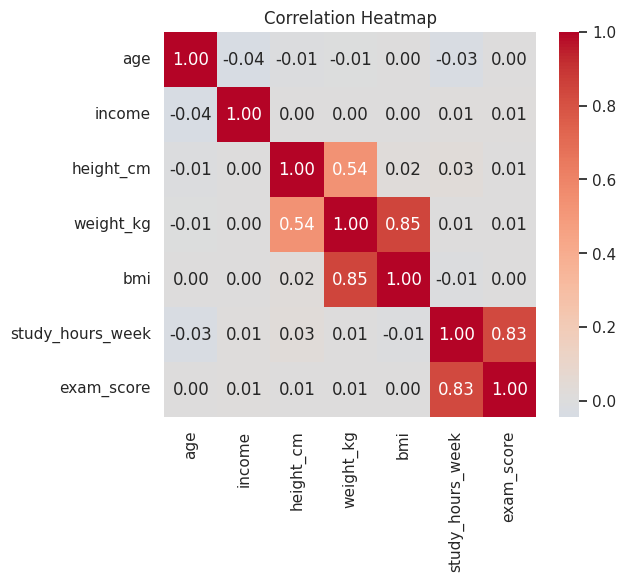

In [21]:
corr_cols = ['age', 'income', 'height_cm', 'weight_kg', 'bmi', 'study_hours_week', 'exam_score']
corr = df[corr_cols].corr()
plot_correlation_heatmap(corr, save_as='heatmap_correlation.png')
plt.show()


**Conclusion:** Study hours and exam score show a very strong,
positive relationship (Pearson r = 0.829, Spearman ρ = 0.783, both
p < 0.001). Spearman is treated as the primary result here since
study_hours_week is right-skewed.

## 9. Regression Analysis

### 9.1 Simple linear regression
**Question:** Does weekly study time predict exam score?

In [22]:
model_simple = linear_regression(df, 'exam_score', ['study_hours_week'])
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     4381.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:47:58   Log-Likelihood:                -7116.9
No. Observations:                2000   AIC:                         1.424e+04
Df Residuals:                    1998   BIC:                         1.425e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               40.3834      0.326  

### 9.2 Multiple linear regression
**Question:** Does age add predictive power beyond study hours?

In [23]:
model_multi = linear_regression(df, 'exam_score', ['study_hours_week', 'age'])
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     2195.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:47:58   Log-Likelihood:                -7115.0
No. Observations:                2000   AIC:                         1.424e+04
Df Residuals:                    1997   BIC:                         1.425e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               39.0506      0.757  

**Conclusion:** Study hours alone explain 68.7% of the variance in
exam score (R² = 0.687, β = 2.89, p < 0.001). Adding age does not
improve the model at all (R² unchanged at 0.687); age's own
coefficient sits right at the edge of significance (p = 0.051),
consistent with age having no real effect on exam score by the
design of this dataset.

### 9.3 Logistic regression
**Question:** Do exam score and study hours predict passing the exam?

In [24]:
logit_model = logistic_regression(df, 'passed_exam', ['exam_score', 'study_hours_week'])
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.554262
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            passed_exam   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1997
Method:                           MLE   Df Model:                            2
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1625
Time:                        05:47:58   Log-Likelihood:                -1108.5
converged:                       True   LL-Null:                       -1323.6
Covariance Type:            nonrobust   LLR p-value:                 3.785e-94
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -4.0692      0.295    -13.800      0.000      -4.647      -3.491
exam_score 

In [25]:
odds_ratios(logit_model)


const               0.017091
exam_score          1.087943
study_hours_week    0.980629
dtype: float64

**Conclusion:** exam_score is a strong, significant predictor of
passing (OR = 1.088, p < 0.001) — each extra point increases the odds
of passing by about 8.8%. study_hours_week is not significant once
exam_score is in the model (p = 0.414), likely due to multicollinearity
(the two variables correlate at r = 0.829) — study hours' effect on
passing is already captured through exam_score.

## 10. Summary of Findings

| # | Question | Test(s) | Result |
|---|---|---|---|
| 1 | Drug vs placebo on score_after | Independent t-test, Mann-Whitney U | Significant, medium effect (d=0.55) |
| 2 | Score before vs after | Paired t-test, Wilcoxon | Significant increase (d=0.77) |
| 3 | Performance across groups A/B/C | One-way ANOVA, Tukey HSD | Significant, all pairs differ (η²=0.10) |
| 4 | Smoking vs disease | Chi-square | Significant association (V=0.30) |
| 5 | Study hours vs exam score | Pearson, Spearman | Very strong positive correlation (ρ=0.78) |
| 6 | Predicting exam score | Linear regression | Study hours explain 68.7% of variance |
| 7 | Predicting exam pass/fail | Logistic regression | Exam score predicts passing (OR=1.09) |

**Skills demonstrated:**
- Data cleaning: missing-value imputation tailored to distribution shape,
  IQR/Z-score outlier detection, log-transform diagnostics, winsorizing,
  fixing a data-generation bug at its source
- Descriptive statistics: mean/median/mode, variance, skewness, kurtosis
- Normality testing and choosing parametric vs non-parametric tests accordingly
- t-tests (independent, paired), ANOVA + post-hoc, chi-square — each with
  the matching effect size (Cohen's d, eta squared, Cramer's V)
- Correlation (Pearson & Spearman) and regression (linear & logistic)
  with odds ratios
- Modular, documented, reusable Python code organized into a `src/` package
